# Exploratory Data Analysis

In [1]:
# Importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

## Loading the Data

In [2]:
# Loading the data

df_transactions = pd.read_csv('../data/train_transaction.csv')
df_identity = pd.read_csv('../data/train_identity.csv')

## Inspecting the Data

In [3]:
# Inspecting data size

print(f'Transaction Dataset Shape: {df_transactions.shape}')
print(f'Identity Dataset Shape: {df_identity.shape}')

Transaction Dataset Shape: (590540, 394)
Identity Dataset Shape: (144233, 41)


In [4]:
# Investigating imbalance in the target variable ('isFraud')

print(df_transactions['isFraud'].value_counts())
print()
print(df_transactions['isFraud'].value_counts(normalize=True).round(4))

isFraud
0    569877
1     20663
Name: count, dtype: int64

isFraud
0    0.965
1    0.035
Name: proportion, dtype: float64


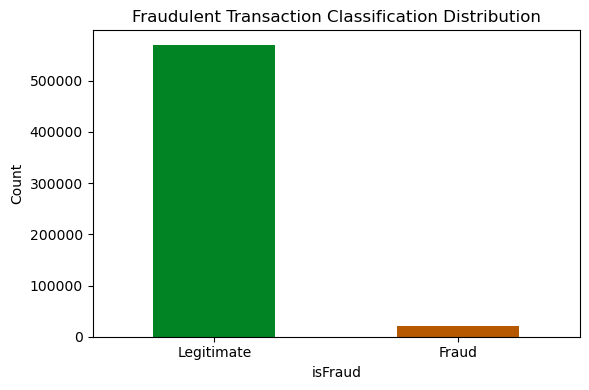

In [5]:
# Visualising imbalance in the target variable

plt.figure(figsize=(6, 4))
df_transactions['isFraud'].value_counts().plot(kind='bar', color=['#018524', '#b55800'])
plt.xticks([0, 1], ['Legitimate', 'Fraud'], rotation=0)
plt.title('Fraudulent Transaction Classification Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

There is a large class imbalance between legitimate and fraudulent transactions, which will pose the problem of the model classifying every transaction as legitimate due to the model being trained on mostly legitimate transaction data, also known as the **dummy classifier problem**. The evaluation metric more suitable for this case than accuracy is AUC-ROC, which measures how well the model distinguishes fraudulent transactions from legitimate.

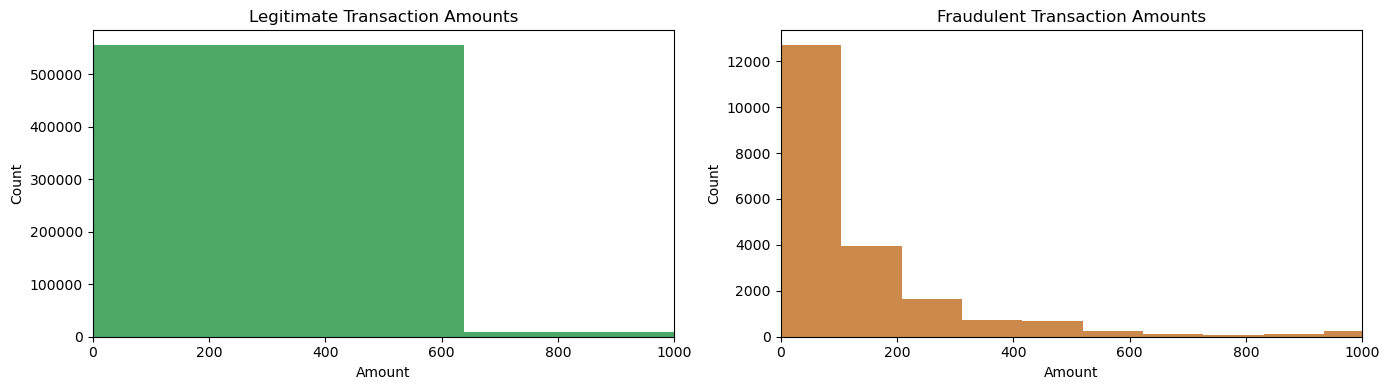

Legitimate Transactions - Median Amount: $68.5
Fraudulent Transactions - Median Amount: $75.0


In [6]:
# Comparing transaction amounts for legitimate and fraudulent transactions

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Legitimate transactions
axes[0].hist(df_transactions[df_transactions['isFraud'] == 0]['TransactionAmt'], bins=50, color='#018524', alpha=0.7)
axes[0].set_title('Legitimate Transaction Amounts')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Count')
axes[0].set_xlim(0, 1000)

# Fraudulent transactions
axes[1].hist(df_transactions[df_transactions['isFraud'] == 1]['TransactionAmt'], bins=50, color='#b55800', alpha=0.7)
axes[1].set_title('Fraudulent Transaction Amounts')
axes[1].set_xlabel('Amount')
axes[1].set_ylabel('Count')
axes[1].set_xlim(0, 1000)

plt.tight_layout()
plt.show()

# Summary Statistics
print(f'Legitimate Transactions - Median Amount: ${df_transactions[df_transactions['isFraud'] == 0]['TransactionAmt'].median()}')
print(f'Fraudulent Transactions - Median Amount: ${df_transactions[df_transactions['isFraud'] == 1]['TransactionAmt'].median()}')

The transaction amounts are heavily right-skewed, so they will be log-transformed to stabilise the distribution to allow for easier learning by the model.

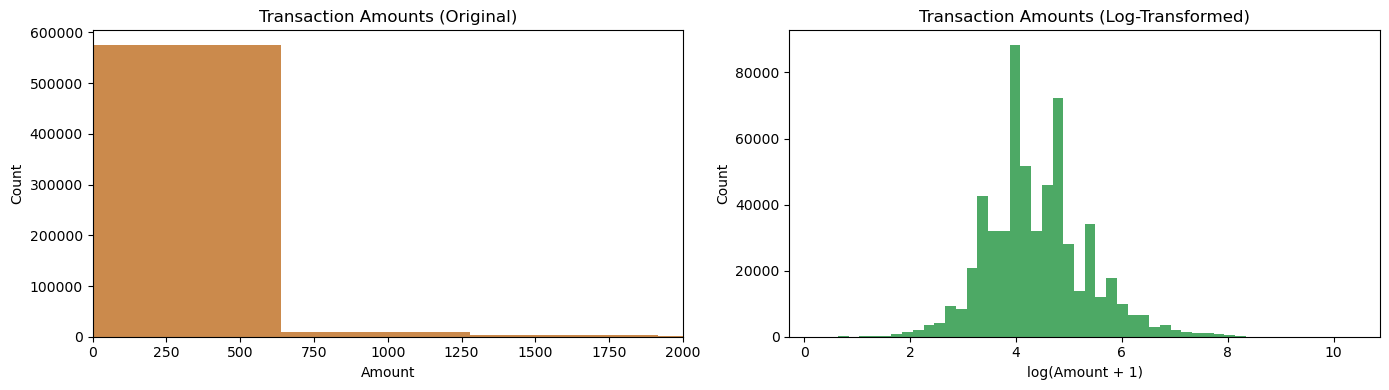

Log transform applied.
count    590540.000
mean          4.383
std           0.937
min           0.224
25%           3.791
50%           4.245
75%           4.836
max          10.372
Name: TransactionAmt, dtype: float64


In [7]:
# Log-transforming transaction amounts

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Before log-transforming
axes[0].hist(df_transactions['TransactionAmt'], bins=50, color='#b55800', alpha=0.7)
axes[0].set_title('Transaction Amounts (Original)')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Count')
axes[0].set_xlim(0, 2000)

# After log-transforming
axes[1].hist(np.log1p(df_transactions['TransactionAmt']), bins=50, color='#018524', alpha=0.7)
axes[1].set_title('Transaction Amounts (Log-Transformed)')
axes[1].set_xlabel('log(Amount + 1)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

# Applying the log transformation
df_transactions['TransactionAmt'] = np.log1p(df_transactions['TransactionAmt'])
print('Log transform applied.')
print(df_transactions['TransactionAmt'].describe().round(3))

### EDA Insight 1

Transaction amount alone is not a strong signal indicating fraudulent transactions.

Legitimate and fraudulent transactions have similar distributions (in the sense that they are right-skewed before log-transforming) and medians ($68.50 vs $75).

The model will need to combine multiple features to accurately and effectively flag fraudulent transactions.

In [8]:
# Fraud rate by ProductCD

product_fraud = df_transactions.groupby('ProductCD')['isFraud'].agg(['sum', 'count'])
product_fraud['fraud_rate'] = (product_fraud['sum'] / product_fraud['count'] * 100).round(2)
product_fraud.columns = ['fraud_count', 'total_count', 'fraud_rate_%']
print(product_fraud.sort_values('fraud_rate_%', ascending=False))

           fraud_count  total_count  fraud_rate_%
ProductCD                                        
C                 8008        68519         11.69
S                  686        11628          5.90
H                 1574        33024          4.77
R                 1426        37699          3.78
W                 8969       439670          2.04


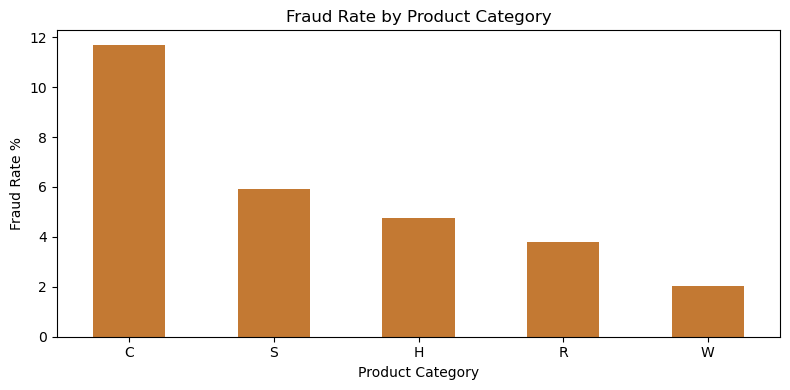

In [9]:
product_fraud['fraud_rate_%'].sort_values(ascending=False).plot(kind='bar', color='#b55800', alpha=0.8, figsize=(8, 4))
plt.title('Fraud Rate by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Fraud Rate %')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### EDA Insight 2

Product category 'C' has a significantly higher fraud rate percentage than the other categories.

Product category is likely a strong predictive signal/feature, as it suggests fraud is concentrated in specific transaction types, not spread evenly.

In [10]:
# Analysing missing values in the transaction dataset

transactions_missing = df_transactions.isnull().sum()
transactions_missing_pct = (transactions_missing / len(df_transactions) * 100).round(2)

df_transactions_missing = pd.DataFrame({
    'missing_count': transactions_missing,
    'missing_%': transactions_missing_pct
}).sort_values('missing_%', ascending=False)

# Showing only columns that have missing values
print(df_transactions_missing[df_transactions_missing['missing_count'] > 0].head(20))
print(f'\nTotal number of columns with missing values: {(df_transactions_missing['missing_count'] > 0).sum()}')

       missing_count  missing_%
dist2         552913      93.63
D7            551623      93.41
D13           528588      89.51
D14           528353      89.47
D12           525823      89.04
D6            517353      87.61
D9            515614      87.31
D8            515614      87.31
V153          508595      86.12
V140          508595      86.12
V150          508589      86.12
V149          508595      86.12
V155          508595      86.12
V147          508595      86.12
V146          508595      86.12
V145          508589      86.12
V144          508589      86.12
V143          508589      86.12
V142          508595      86.12
V141          508595      86.12

Total number of columns with missing values: 374


Many rows have missing values, which simulates worst-case scenarios in real-world financial data.
To overcome this, three strategies will be used:
1. Columns with 90% of records being missing will be dropped, as there is not enough data for the model to learn from in those columns.
2. Missing data from numerical columns will be filled with -999 to signal to the tree-based model to treat these values as their own category (missing).
3. Missing data from categorical columns will be filled with the string 'unknown' for the same reason.

In [11]:
# Applying missing-value-handling strategies for the transaction dataset

# Dropping columns with >90% missing values
transactions_dropped_cols = df_transactions_missing[df_transactions_missing['missing_%'] > 90].index.tolist()
df_transactions = df_transactions.drop(columns=transactions_dropped_cols)
print(f'\nDropped {len(transactions_dropped_cols)} columns: {transactions_dropped_cols}')
print(f'Remaining columns: {df_transactions.shape[1]}')

# Distinguishing between numerical and categorical columns
transactions_num_cols = df_transactions.select_dtypes(include=np.number).columns.tolist()
transactions_num_cols = [col for col in transactions_num_cols if col != 'isFraud'] # Ensuring that the target variable remains untouched
transactions_cat_cols = df_transactions.select_dtypes(include='object').columns.tolist()
print(f'\nNumerical columns: {len(transactions_num_cols)}')
print(f'Categorical columns: {len(transactions_cat_cols)}')

# Filling missing values
df_transactions[transactions_num_cols] = df_transactions[transactions_num_cols].fillna(-999)
df_transactions[transactions_cat_cols] = df_transactions[transactions_cat_cols].fillna('unknown')

# Verifying changes
print(f'\nNumber of missing values after changes: {df_transactions.isnull().sum().sum()}')


Dropped 2 columns: ['dist2', 'D7']
Remaining columns: 392

Numerical columns: 377
Categorical columns: 14

Number of missing values after changes: 0


In [12]:
# Examining categorical columns and unique values in the transaction dataset

for col in transactions_cat_cols:
    print(f'{col:20s} - {df_transactions[col].nunique()} unique values - top 3: {df_transactions[col].value_counts().index[:3].tolist()}')

ProductCD            - 5 unique values - top 3: ['W', 'C', 'R']
card4                - 5 unique values - top 3: ['visa', 'mastercard', 'american express']
card6                - 5 unique values - top 3: ['debit', 'credit', 'unknown']
P_emaildomain        - 60 unique values - top 3: ['gmail.com', 'yahoo.com', 'unknown']
R_emaildomain        - 61 unique values - top 3: ['unknown', 'gmail.com', 'hotmail.com']
M1                   - 3 unique values - top 3: ['T', 'unknown', 'F']
M2                   - 3 unique values - top 3: ['T', 'unknown', 'F']
M3                   - 3 unique values - top 3: ['unknown', 'T', 'F']
M4                   - 4 unique values - top 3: ['unknown', 'M0', 'M2']
M5                   - 3 unique values - top 3: ['unknown', 'F', 'T']
M6                   - 3 unique values - top 3: ['F', 'T', 'unknown']
M7                   - 3 unique values - top 3: ['unknown', 'F', 'T']
M8                   - 3 unique values - top 3: ['unknown', 'F', 'T']
M9                   - 3 uni

For tree-based models, label encoding will be used to encode these categorical features instead of one-hot encoding. This is because tree-based models do not pay much attention to the numerical order of the encoded values and can efficiently handle label-encoded data, and one-hot encoding will take up unnecessary space by creating lots of new columns.

In [13]:
# Encoding categorical values in the transaction dataset with label encoding

le = LabelEncoder()

for col in transactions_cat_cols:
    df_transactions[col] = le.fit_transform(df_transactions[col].astype(str))

print('Encoding completed.')
print(df_transactions[transactions_cat_cols].head(3))

Encoding completed.
   ProductCD  card4  card6  P_emaildomain  R_emaildomain  M1  M2  M3  M4  M5  \
0          4      1      1             48             49   1   1   1   2   0   
1          4      2      1             16             49   2   2   2   0   1   
2          4      4      2             35             49   1   1   1   0   0   

   M6  M7  M8  M9  
0   1   2   2   2  
1   1   2   2   2  
2   0   0   0   0  


In [14]:
# Analysing missing values in the identity dataset

identity_missing = df_identity.isnull().sum()
identity_missing_pct = (identity_missing / len(df_identity) * 100).round(2)

df_identity_missing = pd.DataFrame({
    'missing_count': identity_missing,
    'missing_%': identity_missing_pct
}).sort_values('missing_%', ascending=False)

# Showing only columns that have missing values
print(df_identity_missing[df_identity_missing['missing_count'] > 0].head(20))
print(f'\nTotal number of columns with missing values: {(df_identity_missing['missing_count'] > 0).sum()}')

            missing_count  missing_%
id_24              139486      96.71
id_25              139101      96.44
id_07              139078      96.43
id_08              139078      96.43
id_21              139074      96.42
id_22              139064      96.42
id_23              139064      96.42
id_27              139064      96.42
id_26              139070      96.42
id_18               99120      68.72
id_04               77909      54.02
id_03               77909      54.02
id_33               70944      49.19
id_10               69307      48.05
id_09               69307      48.05
id_30               66668      46.22
id_32               66647      46.21
id_34               66428      46.06
id_14               64189      44.50
DeviceInfo          25567      17.73

Total number of columns with missing values: 38


The above output shows the same situation as the transaction dataset, where the same strategies will be applied to handle missing values.

In [15]:
# Applying missing-value-handling strategies for the identity dataset

# Dropping columns with >90% missing values
identity_dropped_cols = df_identity_missing[df_identity_missing['missing_%'] > 90].index.tolist()
df_identity = df_identity.drop(columns=identity_dropped_cols)
print(f'\nDropped {len(identity_dropped_cols)} columns: {identity_dropped_cols}')
print(f'Remaining columns: {df_identity.shape[1]}')

# Distinguishing between numerical and categorical columns
identity_num_cols = df_identity.select_dtypes(include=np.number).columns.tolist()
identity_num_cols = [col for col in identity_num_cols if col != 'isFraud'] # Ensuring that the target variable remains untouched
identity_cat_cols = df_identity.select_dtypes(include='object').columns.tolist()
print(f'\nNumerical columns: {len(identity_num_cols)}')
print(f'Categorical columns: {len(identity_cat_cols)}')

# Filling missing values
df_identity[identity_num_cols] = df_identity[identity_num_cols].fillna(-999)
df_identity[identity_cat_cols] = df_identity[identity_cat_cols].fillna('unknown')

# Verifying changes
print(f'\nNumber of missing values after changes: {df_identity.isnull().sum().sum()}')


Dropped 9 columns: ['id_24', 'id_25', 'id_07', 'id_08', 'id_21', 'id_22', 'id_23', 'id_27', 'id_26']
Remaining columns: 32

Numerical columns: 17
Categorical columns: 15

Number of missing values after changes: 0


In [16]:
# Examining categorical columns and unique values in the identity dataset

for col in identity_cat_cols:
    print(f'{col:20s} - {df_identity[col].nunique()} unique values - top 3: {df_identity[col].value_counts().index[:3].tolist()}')

id_12                - 2 unique values - top 3: ['NotFound', 'Found']
id_15                - 4 unique values - top 3: ['Found', 'New', 'Unknown']
id_16                - 3 unique values - top 3: ['Found', 'NotFound', 'unknown']
id_28                - 3 unique values - top 3: ['Found', 'New', 'unknown']
id_29                - 3 unique values - top 3: ['Found', 'NotFound', 'unknown']
id_30                - 76 unique values - top 3: ['unknown', 'Windows 10', 'Windows 7']
id_31                - 131 unique values - top 3: ['chrome 63.0', 'mobile safari 11.0', 'mobile safari generic']
id_33                - 261 unique values - top 3: ['unknown', '1920x1080', '1366x768']
id_34                - 5 unique values - top 3: ['unknown', 'match_status:2', 'match_status:1']
id_35                - 3 unique values - top 3: ['T', 'F', 'unknown']
id_36                - 3 unique values - top 3: ['F', 'T', 'unknown']
id_37                - 3 unique values - top 3: ['T', 'F', 'unknown']
id_38                -

In [17]:
# Encoding categorical values in the transaction dataset with label encoding

for col in identity_cat_cols:
    df_identity[col] = le.fit_transform(df_identity[col].astype(str))

print('Encoding completed.')
print(df_identity[identity_cat_cols].head(3))

Encoding completed.
   id_12  id_15  id_16  id_28  id_29  id_30  id_31  id_33  id_34  id_35  \
0      1      1      1      1      1      7    123    164      3      1   
1      1      1      1      1      1     63     98     48      2      1   
2      1      0      0      0      0     75     44    260      4      0   

   id_36  id_37  id_38  DeviceType  DeviceInfo  
0      0      1      1           1         954  
1      0      0      1           1        1727  
2      0      1      1           0        1598  


In [18]:
# Merging the transaction and identity datasets together

df = df_transactions.merge(df_identity, on='TransactionID', how='left')

# Filling missing identity columns introduced by left merging
new_cat_cols = [col for col in identity_cat_cols if col in df.columns]
new_num_cols = [col for col in identity_num_cols if col in df.columns]
df[new_cat_cols] = df[new_cat_cols].fillna('unknown')
df[new_num_cols] = df[new_num_cols].fillna(-999)

print(f'Merged dataset shape: {df.shape}')
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'Fraud rate preserved: {df['isFraud'].mean().round(4)}')

Merged dataset shape: (590540, 423)
Missing values: 0
Fraud rate preserved: 0.035


As shown by the output above, the merged dataset did not lose any columns and preserved the fraud rate. However, there is one more thing to check, which is whether there are any object columns containing mixed types, and null values inside these columns will introduce an error when exporting the dataset.

In [19]:
# Filling any missing values in object columns in the merged dataset

# Finding object columns containing mixed types
object_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Object columns: {object_cols}')

# Filling missing values in object columns and re-encoding
for col in object_cols:
    df[col] = df[col].fillna('unknown')
    df[col] = le.fit_transform(df[col].astype(str))

# Fixing any remaining float nulls in numerical columns
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols = [col for col in num_cols if col != 'isFraud']
df[num_cols] = df[num_cols].fillna(-999)

print(f'Missing values: {df.isnull().sum().sum()}')
print(f'Object columns: {df.select_dtypes(include='object').shape[1]}')

Object columns: ['id_12', 'id_15', 'id_16', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']
Missing values: 0
Object columns: 0


In [20]:
df.to_parquet('../data/df_clean.parquet', index=False)
print(f'Saved: {df.shape}')

Saved: (590540, 423)


This concludes the EDA phase, which has provided useful insights and prepared the data for the next phase, which is feature engineering.